# (25) deep dec — celeba

**Motivation**: host = ```yoru```, device = ```cuda:1``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_TemporalSC'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## Make a model

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('CelebA', model_type, 'ngd|deep')

t_train = 8

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 1/8 * t_train

cfg_vae['latent_channels'] = 512
cfg_vae['latent_pixels'] = 4

# cfg_tr['batch_size'] = 100
# cfg_tr['epochs'] = 40

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

101700

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  2.8 Mil   |
|     ———     |    ———     |
|    layer    |  2.8 Mil   |
+-------------+------------+

poisson_CelebA_t-8_b-1_kms-(512,4,1)_<ngd|deep>
b80-ep50-lr(5e-05)_temp(0.05)_gr(8000)_(2025_07_26,18:49)

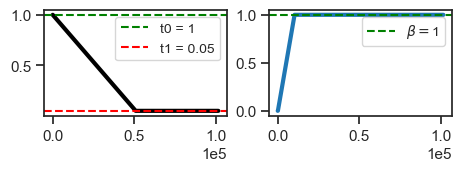

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
model.layer.n_exp

tensor([10, 10, 10, 10, 10, 10, 10, 10], device='cuda:1', dtype=torch.int32)

In [7]:
print(f"{tr.model.layer}") # \n{tr.model.layer.dec}")

PoissonLayer(latent_sz=(512, 4, 4), input_sz=(3, 128, 128), temp=1)

In [8]:
print_num_params(tr.model.layer.dec)

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|  Sequential |  2.8 Mil   |
|     ———     |    ———     |
|      0      |  262.7 K   |
|      1      |  1.3 Mil   |
|      2      |  590.1 K   |
|      3      |  327.9 K   |
|      4      |  147.6 K   |
|      5      |   82.0 K   |
|      6      |   36.9 K   |
|      7      |   20.5 K   |
|      8      |   9.2 K    |
|      9      |   5.2 K    |
|      10     |   2.3 K    |
|      11     |     51     |
+-------------+------------+

In [9]:
tr.model.layer.dec

Sequential(
  (0): Conv2D(
    (_layer): Conv2d(512, 512, kernel_size=(1, 1), stride=(1, 1), padding=valid)
  )
  (1): Cell(
    (skip): Sequential(
      (0): Upsample(scale_factor=2.0, mode='nearest')
      (1): Conv2D(
        (_layer): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
      )
    )
    (ops): ModuleList(
      (0): ConvLayer(
        (upsample): Upsample(scale_factor=2.0, mode='nearest')
        (act_fn): SiLU()
        (conv): Conv2D(
          (_layer): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
    )
  )
  (2): Cell(
    (skip): Identity()
    (ops): ModuleList(
      (0): ConvLayer(
        (act_fn): SiLU()
        (conv): Conv2D(
          (_layer): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
    )
  )
  (3): Cell(
    (skip): Sequential(
      (0): Upsample(scale_factor=2.0, mode='nearest')
      (1): Conv2D(
        (_layer): Conv2d(256, 128, kernel_size=(1, 1), stride=(1,

In [10]:
tr.model.cfg.set_clamp_val('u', 5.0)
tr.model.cfg.set_clamp_val('du', 5.0)

tr.model.cfg.clamp_vals

{'u': (5.0,), 'du': (5.0,), 'dec': 3.45}

In [11]:
tr.model.layer.u_init[0].shape, tr.model.layer.log_bias.shape

(torch.Size([1, 512, 1, 1]), torch.Size([1, 512, 1, 1]))

In [12]:
tr.train('no-se')

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 50, avg loss: 1709.279: 100%|██████| 50/50 [57:27:52<00:00, 4137.46s/it]


100%|███████████████████████████████████| 5/5 [00:19<00:00,  3.95s/it]


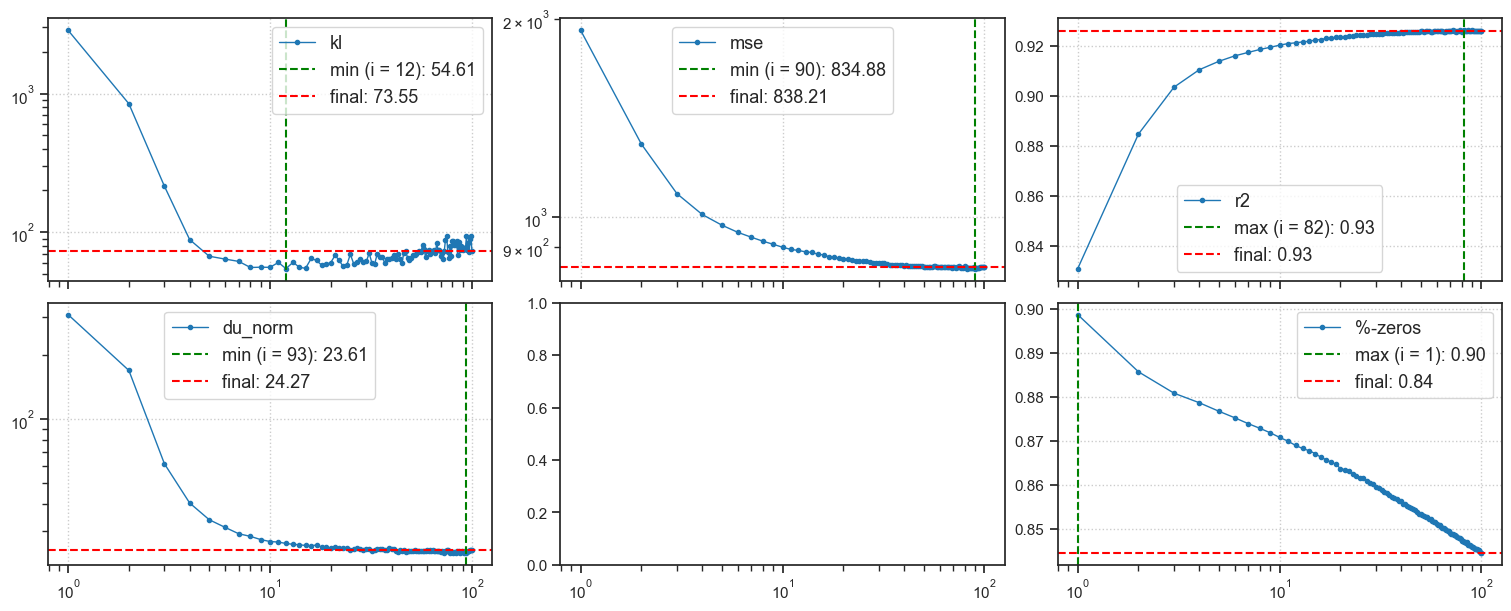

CPU times: user 23.2 s, sys: 325 ms, total: 23.5 s
Wall time: 21.9 s


In [13]:
%%time

kws = dict(
    t_total=100,
    n_data_batches=5,
    compute_sprs=False,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='C0')

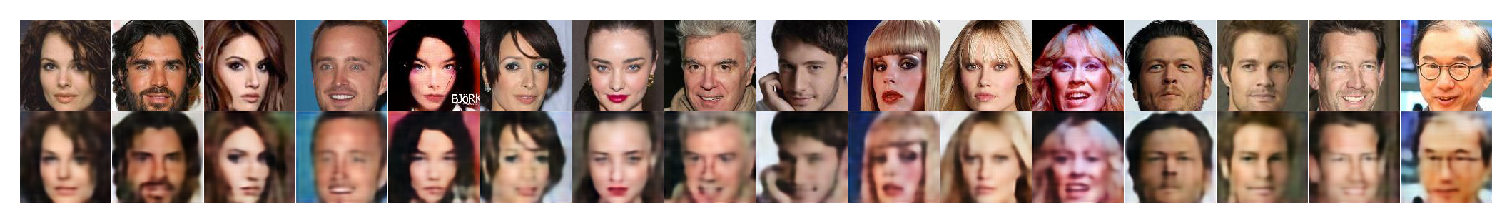

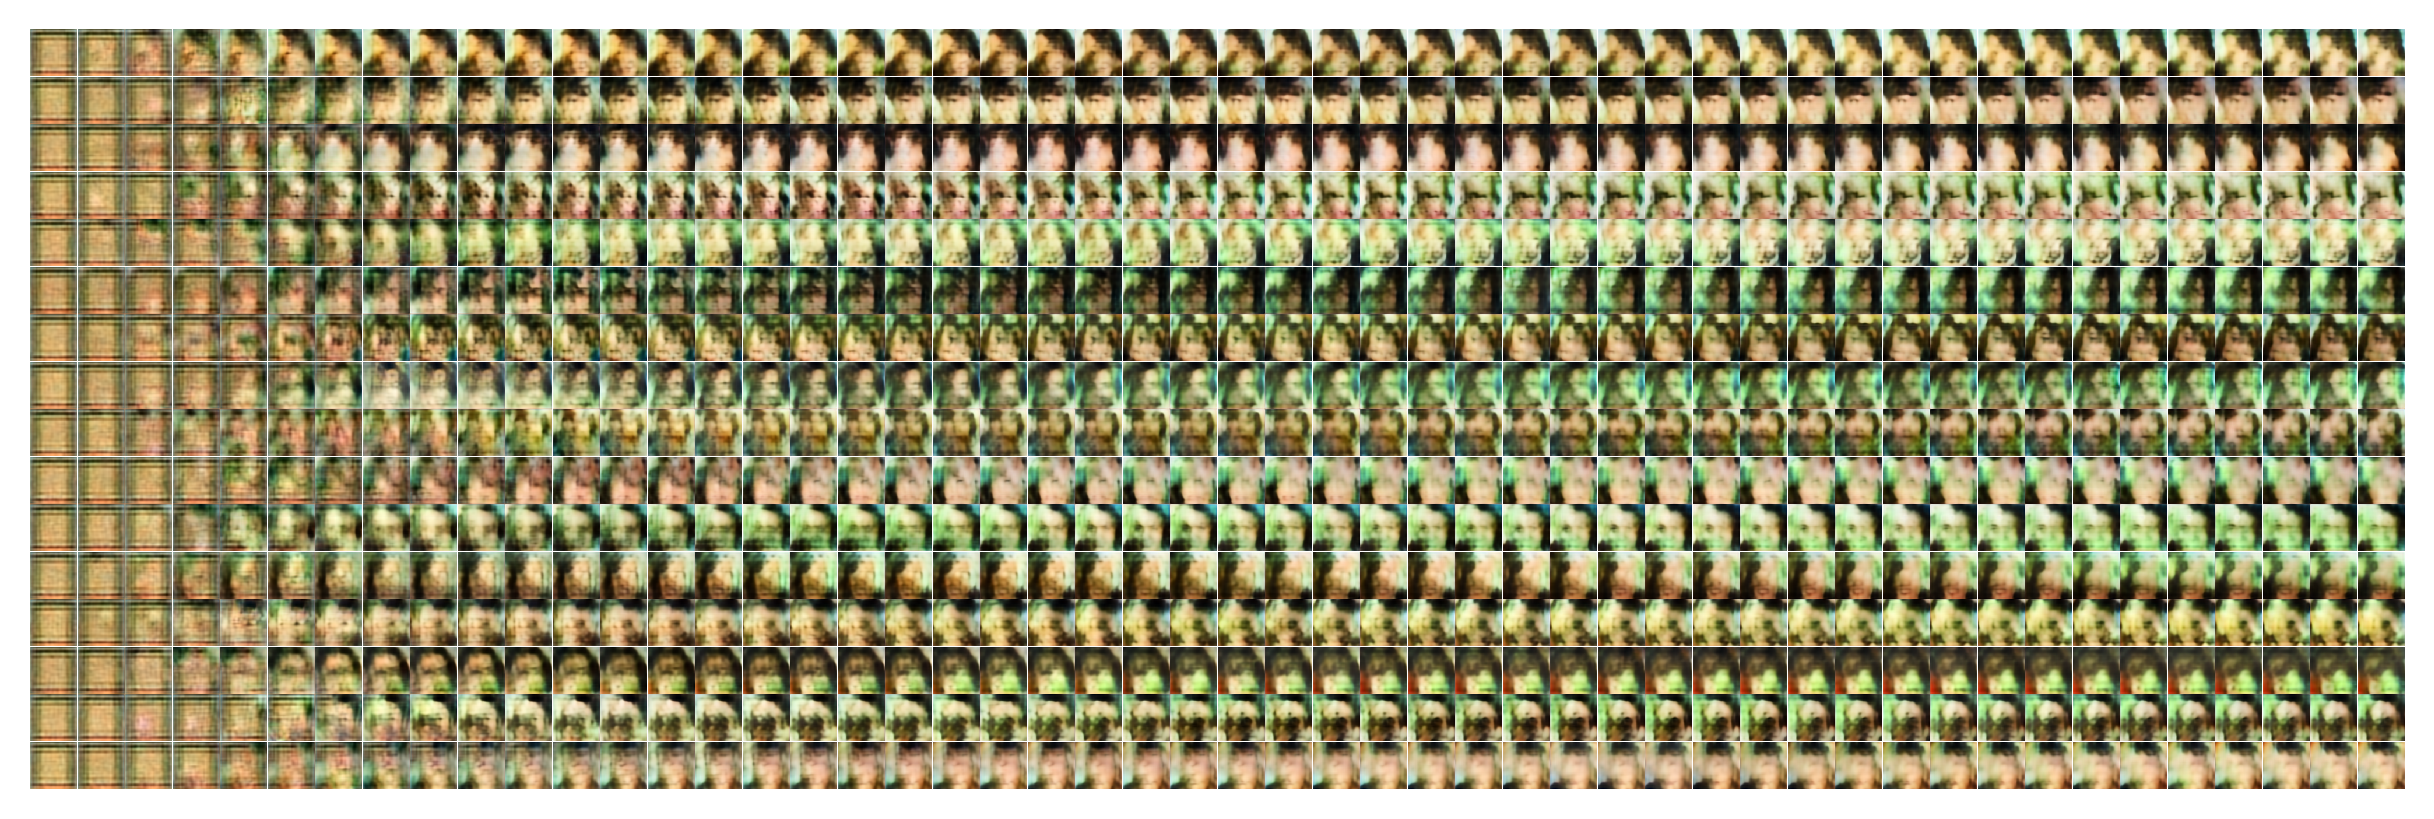

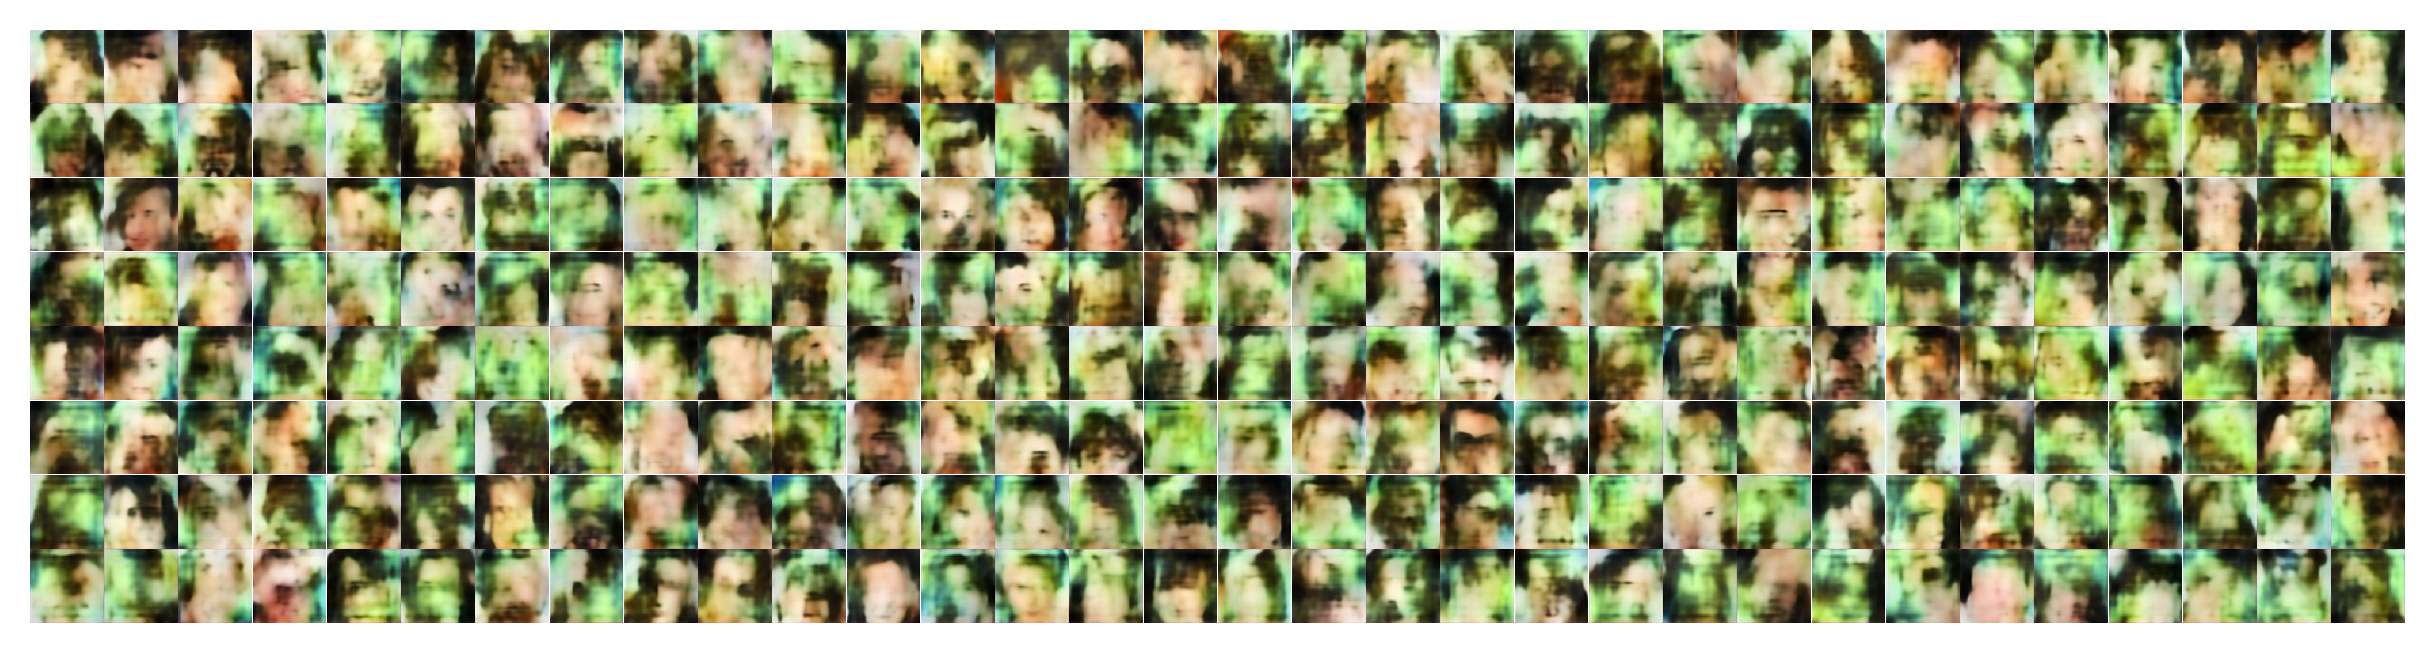

In [14]:
tr.show_recon();
tr.show_samples();

In [20]:
log_bias = tonp(tr.model.layer.log_bias.squeeze())
bias = np.exp(log_bias)
bias.shape

(512,)

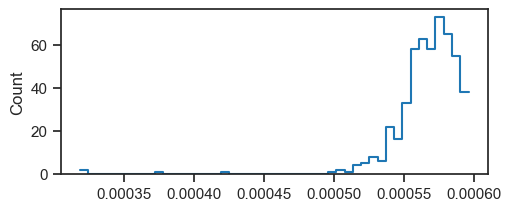

In [21]:
fig, ax = create_figure(1, 1, (5, 2))
histplot(bias.ravel())
plt.show()

In [22]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u0.shape

(512,)

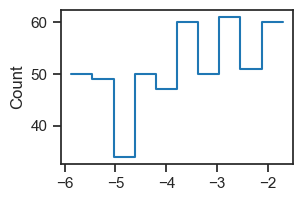

In [23]:
histplot(u0.ravel())
plt.show()

In [24]:
print(sp_stats.pearsonr(u0.ravel(), log_bias.ravel()))

PearsonRResult(statistic=-0.4179651259083709, pvalue=4.5666203791708685e-23)

In [12]:
# a = 'poisson_vH16-wht_t-8_b-4_k-128_m-8_<ngd|lin>'
# b = 'b200-ep300-lr(0.001)_temp(0.05)_gr(200)_ConvPhi:M=8_(2025_06_21,23:44)'
# tr, meta = load_model(pjoin(a, b), device)
# meta['checkpoint']